In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

df = pd.read_csv("E-commerce_Customer_Segmentation_2026.csv")

df.head()

,customer_id,customer_segment,segment_category,age,age_group,gender,country,city,income_bracket,education_level,employment_type,marital_status,tenure_months,total_purchases,avg_order_value_usd,total_spent_usd,purchase_frequency,days_since_last_purchase,preferred_category_1,preferred_category_2,preferred_category_3,shopping_channel,device_used,payment_method,return_count,complaint_count,satisfaction_score,satisfaction_level,loyalty_tier,email_open_rate,click_through_rate,conversion_rate,social_media_presence,customer_lifetime_value_usd,customer_acquisition_cost_usd,customer_profitability_usd,recency_score,frequency_score,monetary_score,rfm_score,churn_risk_score,customer_health_score,dataset_year,customer_value_category,activity_status,health_status,churn_risk_category,rfm_category,profitability_category,engagement_level,behavior_segment,device_preference,clv_category
0,CUST-000001,Consumer,High Value Inactive,70,65+,Male,Canada,Winnipeg,150K+,Professional,Unemployed,Widowed,77,28,912.60,25552.80,Quarterly,63,Sports & Fitness,Home & Kitchen,NaN,In-Store,Tablet,Debit Card,15,13,5,Very Satisfied,Platinum,0.018,0.067,0.022,NaN,21281.07,96.74,21184.33,3,3,4,10,39,100,2026,High,Dormant,Excellent,Low,Potential Loyalists,High Profit,Low,Regular Buyer,Multi-Device,High CLV
1,CUST-000002,Premium,High Value Inactive,53,45-54,Female,Germany,Essen,25K-50K,High School,Student,Divorced,80,75,300.86,22564.50,Rarely,342,Automotive,Beauty,Fashion,Marketplace,Desktop,Bank Transfer,1,14,5,Very Satisfied,Gold,0.084,0.085,0.293,NaN,28347.21,199.28,28147.93,1,4,3,8,42,100,2026,Medium,Inactive,Excellent,Medium,At Risk,High Profit,Low,Occasional Buyer,Desktop-First,High CLV
2,CUST-000003,Consumer,High Value Inactive,82,65+,Male,Mexico,Puebla,75K-100K,Bachelors,Student,Married,86,163,663.91,108217.33,Quarterly,64,Fashion,Automotive,Beauty,In-Store,Tablet,Bank Transfer,1,4,3,Neutral,Diamond,0.279,0.428,0.222,NaN,103909.84,112.39,103797.45,3,5,5,13,0,100,2026,Very High,Dormant,Excellent,Very Low,Champions,High Profit,Low,Regular Buyer,Multi-Device,High CLV
3,CUST-000004,Enterprise,High Value Active,18,18-24,Male,Singapore,Singapore,150K+,Masters,Retired,Divorced,26,192,613.60,117811.20,Weekly,2,Electronics,Toys,NaN,Online,Mobile,Credit Card,11,8,5,Very Satisfied,Diamond,0.899,0.282,0.142,"Twitter, YouTube, TikTok",171318.41,140.71,171177.70,5,5,5,15,14,100,2026,Very High,Active,Excellent,Very Low,Champions,High Profit,High,Frequent Buyer,Mobile-First,High CLV
4,CUST-000005,Premium,High Value Active,64,55-64,Male,United Arab Emirates,Fujairah,150K+,PhD,Retired,Divorced,90,31,651.65,20201.15,Weekly,4,Home & Kitchen,Office Supplies,Grocery,Online,Desktop,Credit Card,7,11,1,Very Dissatisfied,Gold,0.835,0.094,0.180,"TikTok, YouTube",24465.47,52.82,24412.65,5,3,3,11,45,60,2026,Medium,Active,Fair,Medium,Loyal,High Profit,Medium,Occasional Buyer,Desktop-First,High CLV


In [4]:
print("Dataset shape:", df.shape)
print("\nData types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

Dataset shape: (50000, 53)

Data types:
customer_id                       object
customer_segment                  object
segment_category                  object
age                                int64
age_group                         object
gender                            object
country                           object
city                              object
income_bracket                    object
education_level                   object
employment_type                   object
marital_status                    object
tenure_months                      int64
total_purchases                    int64
avg_order_value_usd              float64
total_spent_usd                  float64
purchase_frequency                object
days_since_last_purchase           int64
preferred_category_1              object
preferred_category_2              object
preferred_category_3              object
shopping_channel                  object
device_used                       object
payment_method   

In [5]:
df[["recency_score", "frequency_score", "monetary_score"]].describe().round(2)

,recency_score,frequency_score,monetary_score
count,50000.00,50000.00,50000.00
mean,3.95,4.12,3.72
std,1.48,1.08,1.36
min,1.00,1.00,1.00
25%,3.00,3.00,3.00
50%,5.00,4.00,4.00
75%,5.00,5.00,5.00
max,5.00,5.00,5.00


In [6]:
features = df[["recency_score", "frequency_score", "monetary_score"]]

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

scaled_features[:5]

array([[-0.64508598, -1.04190759,  0.20778446],
       [-1.99741078, -0.11388672, -0.52825684],
       [-0.64508598,  0.81413415,  0.94382576],
       [ 0.70723883,  0.81413415,  0.94382576],
       [ 0.70723883, -1.04190759, -0.52825684]])

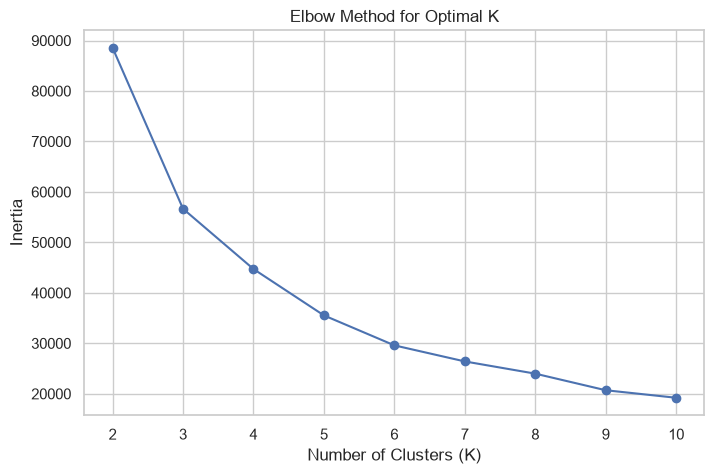

In [7]:
inertia = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), inertia, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")
plt.show()

In [8]:
id="c7k2lm"
list(zip(range(2, 11), inertia))

[(2, 88564.61463064494),
 (3, 56661.40692890392),
 (4, 44719.93881168407),
 (5, 35532.47501053016),
 (6, 29593.702973882962),
 (7, 26409.557999930916),
 (8, 23988.85721336833),
 (9, 20702.51476630997),
 (10, 19210.41058891166)]

In [9]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)

df["cluster"] = kmeans.fit_predict(scaled_features)

df["cluster"].value_counts().sort_index()

cluster
0     9626
1    17165
2     5592
3    12949
4     4668
Name: count, dtype: int64

In [10]:
cluster_profile = df.groupby("cluster")[["recency_score", "frequency_score", "monetary_score"]].mean().round(2)

cluster_profile

,recency_score,frequency_score,monetary_score
cluster,,,
0,1.90,4.74,4.55
1,4.86,4.85,4.82
2,4.69,2.10,1.52
3,4.80,3.95,3.07
4,1.66,3.10,2.35


In [11]:
cluster_names = {
    0: "At-Risk High-Value",
    1: "Champions",
    2: "Recent Low-Value",
    3: "Recent Mid-Value",
    4: "At-Risk Mid-Value"
}

df["segment"] = df["cluster"].map(cluster_names)

df[["customer_id", "cluster", "segment"]].head()

,customer_id,cluster,segment
0,CUST-000001,4,At-Risk Mid-Value
1,CUST-000002,4,At-Risk Mid-Value
2,CUST-000003,0,At-Risk High-Value
3,CUST-000004,1,Champions
4,CUST-000005,3,Recent Mid-Value


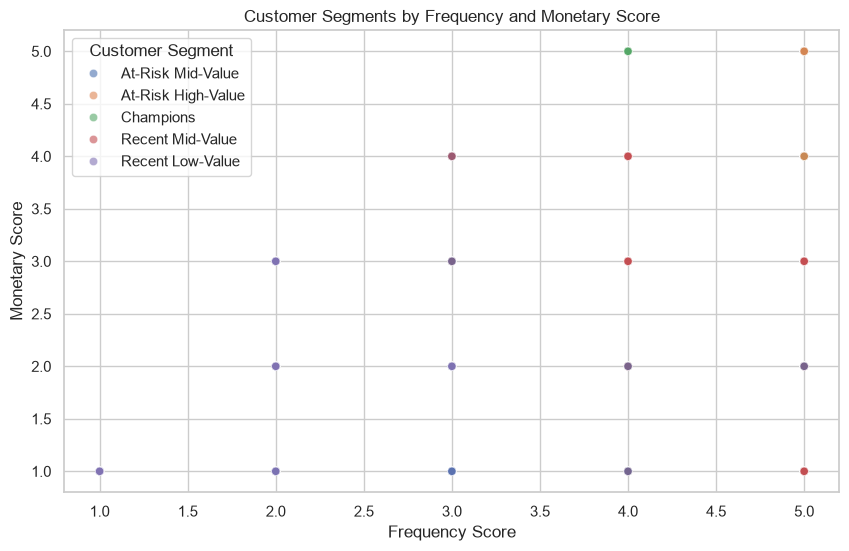

In [12]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="frequency_score", y="monetary_score", hue="segment", alpha=0.6)
plt.title("Customer Segments by Frequency and Monetary Score")
plt.xlabel("Frequency Score")
plt.ylabel("Monetary Score")
plt.legend(title="Customer Segment")
plt.show()

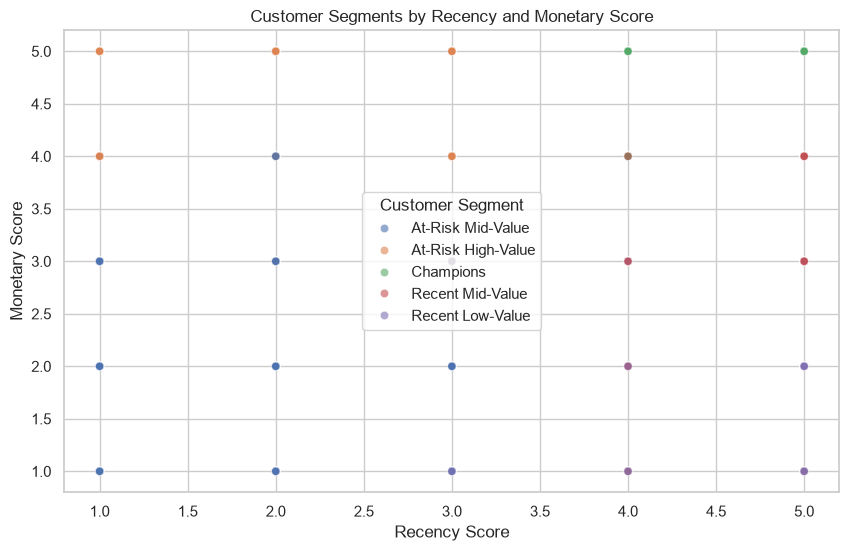

In [13]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="recency_score", y="monetary_score", hue="segment", alpha=0.6)
plt.title("Customer Segments by Recency and Monetary Score")
plt.xlabel("Recency Score")
plt.ylabel("Monetary Score")
plt.legend(title="Customer Segment")
plt.show()

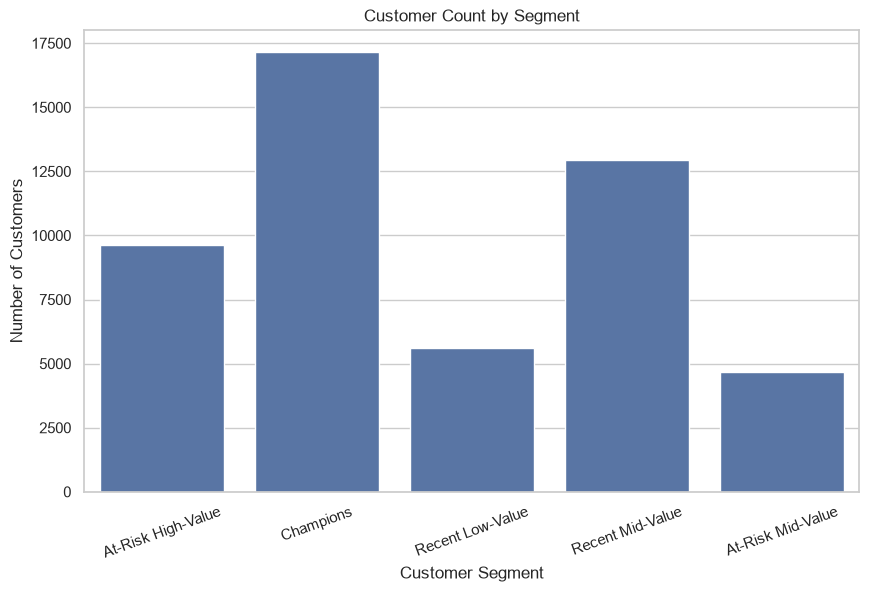

In [14]:
segment_counts = df["segment"].value_counts().reindex(cluster_names.values())

plt.figure(figsize=(10, 6))
sns.barplot(x=segment_counts.index, y=segment_counts.values)
plt.title("Customer Count by Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=20)
plt.show()

In [15]:
final_profile = df.groupby("segment").agg(
    customer_count=("customer_id", "count"),
    avg_recency=("recency_score", "mean"),
    avg_frequency=("frequency_score", "mean"),
    avg_monetary=("monetary_score", "mean")
).round(2)

final_profile = final_profile.reindex(cluster_names.values())

final_profile

,customer_count,avg_recency,avg_frequency,avg_monetary
segment,,,,
At-Risk High-Value,9626,1.90,4.74,4.55
Champions,17165,4.86,4.85,4.82
Recent Low-Value,5592,4.69,2.10,1.52
Recent Mid-Value,12949,4.80,3.95,3.07
At-Risk Mid-Value,4668,1.66,3.10,2.35


In [16]:
recommendations = pd.DataFrame({
    "Segment": [
        "Champions",
        "Recent Mid-Value",
        "At-Risk High-Value",
        "Recent Low-Value",
        "At-Risk Mid-Value"
    ],
    "Marketing Recommendation": [
        "Reward loyalty with exclusive offers, early access, and premium programs.",
        "Encourage repeat purchases with personalized recommendations and targeted promotions.",
        "Use win-back campaigns, personalized discounts, and loyalty incentives to reactivate them.",
        "Use cross-selling, product recommendations, and introductory offers to increase purchase frequency.",
        "Use re-engagement emails, limited-time discounts, and personalized offers to bring them back."
    ]
})

recommendations

,Segment,Marketing Recommendation
0,Champions,"Reward loyalty with exclusive offers, early ac..."
1,Recent Mid-Value,Encourage repeat purchases with personalized r...
2,At-Risk High-Value,"Use win-back campaigns, personalized discounts..."
3,Recent Low-Value,"Use cross-selling, product recommendations, an..."
4,At-Risk Mid-Value,"Use re-engagement emails, limited-time discoun..."


In [17]:
findings = {
    "Key Finding 1": "Champions form the largest customer segment with 17,165 customers and show high recency, frequency, and monetary scores.",
    "Key Finding 2": "At-Risk High-Value customers have high frequency and monetary scores but low recency, making them an important group for win-back campaigns.",
    "Key Finding 3": "Recent Mid-Value customers represent a large growth opportunity because they are active and can potentially be converted into higher-value customers.",
    "Key Finding 4": "Recent Low-Value customers are active but have lower purchase frequency and monetary value, creating opportunities for cross-selling and upselling.",
    "Key Finding 5": "At-Risk Mid-Value customers require re-engagement strategies to prevent further decline in customer activity."
}

for key, value in findings.items():
    print(f"{key}: {value}")

Key Finding 1: Champions form the largest customer segment with 17,165 customers and show high recency, frequency, and monetary scores.
Key Finding 2: At-Risk High-Value customers have high frequency and monetary scores but low recency, making them an important group for win-back campaigns.
Key Finding 3: Recent Mid-Value customers represent a large growth opportunity because they are active and can potentially be converted into higher-value customers.
Key Finding 4: Recent Low-Value customers are active but have lower purchase frequency and monetary value, creating opportunities for cross-selling and upselling.
Key Finding 5: At-Risk Mid-Value customers require re-engagement strategies to prevent further decline in customer activity.


In [18]:
df[["customer_id", "cluster", "segment"]].isnull().sum()

customer_id    0
cluster        0
segment        0
dtype: int64

In [19]:
df.to_csv("customer_segments.csv", index=False)